<a href="https://colab.research.google.com/github/freditasariph/Praktikum-ADW/blob/main/Tugas_Kelompok_Minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> EKSPLORASI DATA DERET WAKTU: IMPOR BERAS INDONESIA </center></h1>
<center>Kelompok 3 - STA2542 Analisis Deret Waktu</center>
<center>Tugas Kumpul EDA - 18 September 2026</center>

_____________________________________________________________________________________________________________________________


## Deskripsi Data

Data yang digunakan adalah **volume impor beras Indonesia** bulanan dari **April 2014 sampai Mei 2024** (122 observasi), yang diberikan oleh Bu Yeni sebagai studi kasus Kelompok 3. Pada tahap eksplorasi ini, seluruh analisis (plot, ACF/PACF, uji stasioneritas, korelasi, dan transformasi Box-Cox) dilakukan terhadap **data mentah/asli** — penanganan outlier (jika diperlukan) akan diputuskan pada tahap pemodelan ARIMA selanjutnya, bukan pada tahap EDA ini.

In [1]:
!pip install PythonTsa

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import boxcox, boxcox_llf
from scipy.special import inv_boxcox
from PythonTsa.plot_acf_pacf import acf_pacf_fig

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.titleweight"] = "bold"

def show_and_save(filename=None):
    """Helper: rapikan layout, simpan (opsional), lalu tampilkan plot."""
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

def adf_report(series, label):
    """Helper: uji ADF lengkap dengan nilai kritis & kesimpulan otomatis."""
    stat, pval, usedlag, nobs, crit, icbest = adfuller(series.dropna(), autolag='AIC')
    print(f"[ADF] {label}")
    print(f"  Statistik ADF : {stat:.4f} | p-value = {pval:.4f} | lag = {usedlag}")
    for k, v in crit.items():
        print(f"  Critical value {k}: {v:.4f}")
    kesimpulan = "STASIONER (tolak H0)" if pval < 0.05 else "TIDAK STASIONER (gagal tolak H0)"
    print(f"  Kesimpulan: {kesimpulan}")
    return pval

def kpss_report(series, label):
    """Helper: uji KPSS dengan kesimpulan otomatis."""
    stat, pval, lag, crit = sm.tsa.stattools.kpss(series.dropna(), regression="c", nlags="auto")
    print(f"[KPSS] {label}")
    print(f"  Statistik KPSS: {stat:.4f} | p-value = {pval:.4f} | lag = {lag}")
    kesimpulan = "TIDAK STASIONER (tolak H0)" if pval < 0.05 else "STASIONER (gagal tolak H0)"
    print(f"  Kesimpulan: {kesimpulan}")
    return pval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 6.1 MB/s eta 0:00:00


### Import dan Persiapan Data

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel("Impor beras.xlsx")
df.head()

Saving Impor beras.xlsx to Impor beras.xlsx


,period,impor
0,2014-04-01,9150000
1,2014-05-01,6225000
2,2014-06-01,3325000
3,2014-07-01,11668000
4,2014-08-01,16949925


In [3]:
df.tail()

,period,impor
117,2024-01-01,235840001
118,2024-02-01,275999000
119,2024-03-01,142656000
120,2024-04-01,110104000
121,2024-05-01,154303000


In [4]:
df.dtypes

,0
period,datetime64[ns]
impor,int64


In [5]:
df.isnull().sum()

,0
period,0
impor,0


Tidak terdapat *missing value* pada data. Selanjutnya kolom `period` dijadikan indeks waktu bulanan.

In [6]:
df['period'] = pd.to_datetime(df['period'])
df = df.sort_values('period').set_index('period')
y = df['impor'].astype(float)
y.index.freq = "MS"
y.head()

,impor
period,
2014-04-01,9150000.0
2014-05-01,6225000.0
2014-06-01,3325000.0
2014-07-01,11668000.0
2014-08-01,16949925.0


In [7]:
y.describe()

,impor
count,1.220000e+02
mean,3.435742e+07
std,5.543598e+07
min,1.000000e+00
25%,4.688733e+06
50%,9.905000e+06
75%,2.256569e+07
max,2.759990e+08


Terlihat rentang nilai yang sangat lebar, dari minimum **1 Kg** hingga maksimum **275.999.000 Kg**, dengan standar deviasi (55,4 juta) yang lebih besar dari rata-ratanya (34,4 juta). Ini adalah indikasi awal bahwa ragam deret **tidak konstan**.

### Plot Deret Waktu

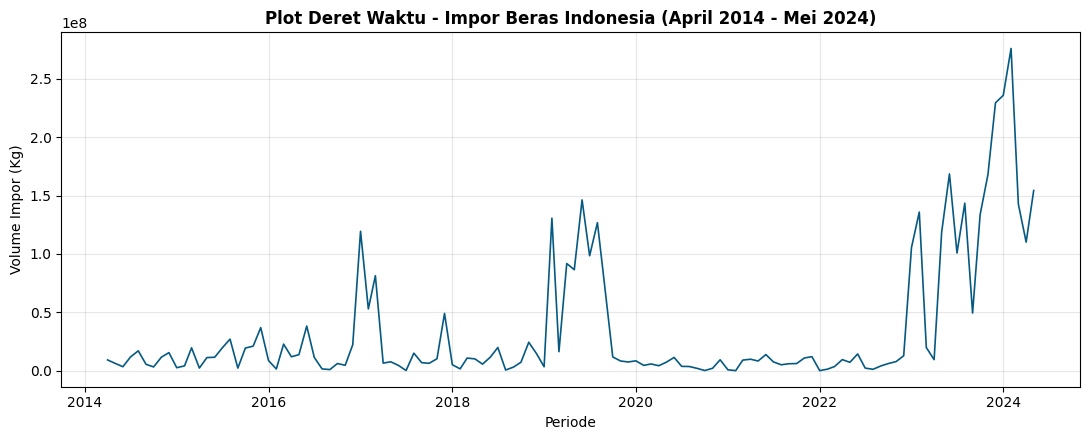

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(y.index, y.values, color="#065A82", lw=1.2)
ax.set_title("Plot Deret Waktu - Impor Beras Indonesia (April 2014 - Mei 2024)")
ax.set_xlabel("Periode"); ax.set_ylabel("Volume Impor (Kg)")
show_and_save("01_plot_data_mentah.png")

**Interpretasi:** Deret menunjukkan fluktuasi yang sangat tajam dengan beberapa periode lonjakan besar (akhir 2016, awal-pertengahan 2019, dan terutama 2023-2024). Terdapat pula periode nilai sangat rendah/mendekati nol (2020-2022, kemungkinan terkait kebijakan swasembada pangan dan pandemi COVID-19). Pola ini mengindikasikan bahwa deret **tidak stasioner**, baik dalam nilai tengah (terdapat pergeseran level, terutama tren naik sejak 2023) maupun dalam ragam (besar fluktuasi jauh berbeda antar periode).

### Catatan Eksplorasi: Identifikasi Nilai Ekstrem (Outlier)

Sebagai bagian dari eksplorasi, dilakukan identifikasi nilai-nilai ekstrem menggunakan metode **IQR pada skala logaritma** (agar dapat menangkap nilai ekstrem di kedua sisi — sangat tinggi maupun mendekati nol), tanpa melakukan penanganan/pembersihan pada tahap ini.

In [9]:
y_log = np.log(y)
Q1 = y_log.quantile(0.25)
Q3 = y_log.quantile(0.75)
IQR = Q3 - Q1
lower_log = Q1 - 1.5 * IQR
upper_log = Q3 + 1.5 * IQR

candidate_mask = (y_log < lower_log) | (y_log > upper_log)
candidates = y[candidate_mask]
print(f"Batas bawah (skala asli): {np.exp(lower_log):,.0f} Kg")
print(f"Batas atas  (skala asli): {np.exp(upper_log):,.0f} Kg")
print(f"\nNilai ekstrem terindikasi ({candidate_mask.sum()} titik):")
candidates

Batas bawah (skala asli): 443,322 Kg
Batas atas  (skala asli): 238,481,806 Kg

Nilai ekstrem terindikasi (5 titik):


,impor
period,
2017-07-01,92510.0
2020-10-01,75000.0
2021-02-01,1.0
2022-01-01,2.0
2024-02-01,275999000.0


**Interpretasi:** Teridentifikasi beberapa bulan dengan nilai impor sangat tinggi (terutama 2019 dan 2023-2024, sejalan dengan kebijakan/krisis pangan pada periode tersebut) maupun sangat rendah/mendekati nol (Feb-2021 = 1 Kg, Jan-2022 = 2 Kg), yang secara domain patut dicurigai sebagai kemungkinan kesalahan pencatatan. **Penanganan terhadap nilai-nilai ini (misalnya interpolasi) akan diputuskan pada tahap pemodelan ARIMA selanjutnya**, bukan pada tahap eksplorasi ini — seluruh analisis berikut tetap menggunakan data asli/mentah.

### Boxplot — Visualisasi Sebaran Data

Boxplot pada skala log memperlihatkan kedua sisi outlier secara lebih proporsional dibandingkan boxplot pada skala asli (yang skalanya didominasi oleh nilai-nilai besar).

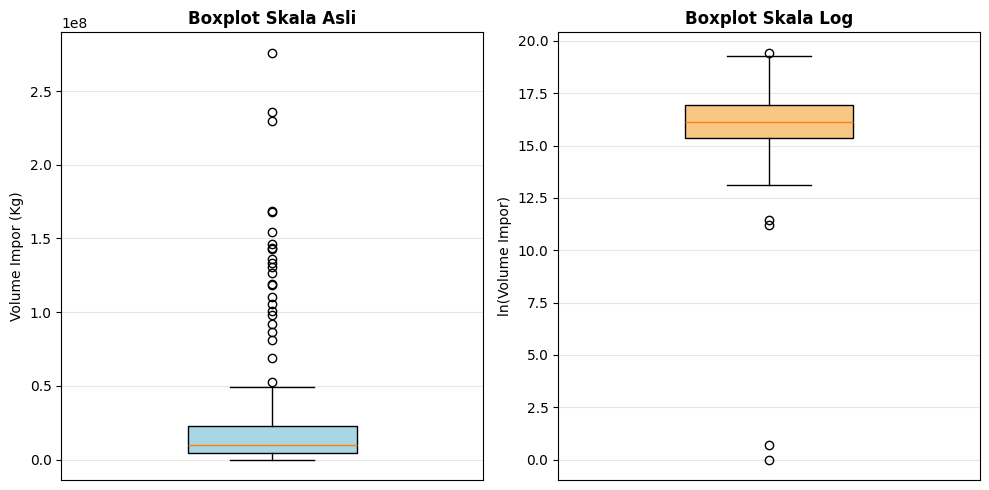

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

bp1 = axes[0].boxplot(y.values, vert=True, patch_artist=True, widths=0.4)
bp1['boxes'][0].set_facecolor("#A9D6E5")
axes[0].set_title("Boxplot Skala Asli")
axes[0].set_ylabel("Volume Impor (Kg)")
axes[0].set_xticks([])

bp2 = axes[1].boxplot(y_log.values, vert=True, patch_artist=True, widths=0.4)
bp2['boxes'][0].set_facecolor("#F9C784")
axes[1].set_title("Boxplot Skala Log")
axes[1].set_ylabel("ln(Volume Impor)")
axes[1].set_xticks([])

show_and_save("01a_boxplot_keseluruhan.png")

**Interpretasi:** Pada skala asli (kiri), boxplot didominasi outlier di sisi atas saja karena skalanya sangat lebar. Pada skala log (kanan), sebaran data terlihat lebih simetris dan nilai ekstrem di kedua sisi menjadi terlihat jelas sebagai titik-titik di luar *whisker*.

### Boxplot Bulanan — Cek Pola Musiman

Boxplot per bulan (menggabungkan seluruh tahun 2014-2024 untuk masing-masing bulan Jan-Des) membantu melihat apakah ada pola musiman yang konsisten setiap tahun, melengkapi hasil dekomposisi.

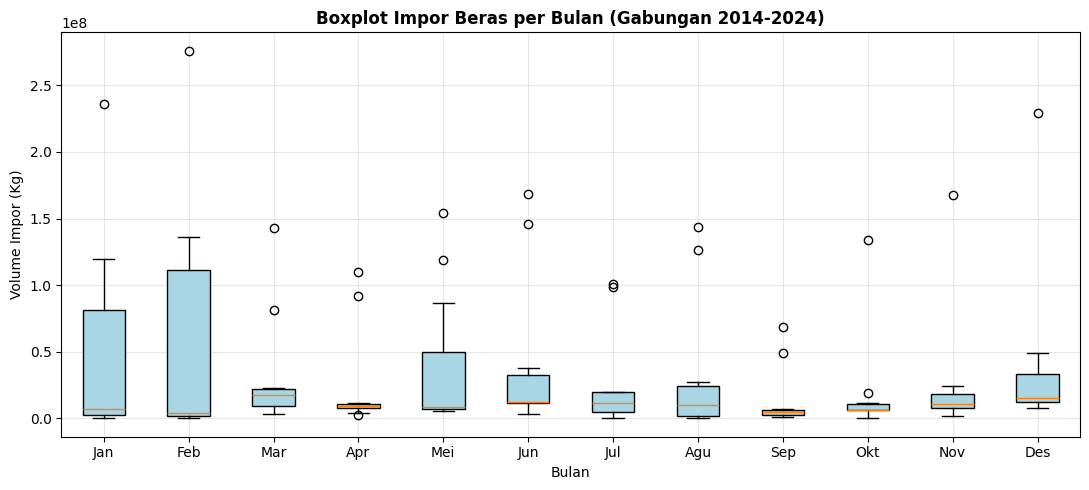

In [11]:
bulan_label = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]
data_per_bulan = [y[y.index.month == m].values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(data_per_bulan, labels=bulan_label, patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor("#A9D6E5")
ax.set_title("Boxplot Impor Beras per Bulan (Gabungan 2014-2024)")
ax.set_xlabel("Bulan"); ax.set_ylabel("Volume Impor (Kg)")
show_and_save("01c_boxplot_bulanan.png")

**Interpretasi:** Tidak terlihat pola musiman yang konsisten dan tajam antar bulan — median tiap bulan relatif berdekatan, dan nilai ekstrem tersebar di berbagai bulan (bukan hanya terkonsentrasi pada bulan tertentu), memperkuat kesimpulan bahwa komponen musiman pada deret ini relatif lemah.

### Plot ACF dan PACF (Data Mentah)

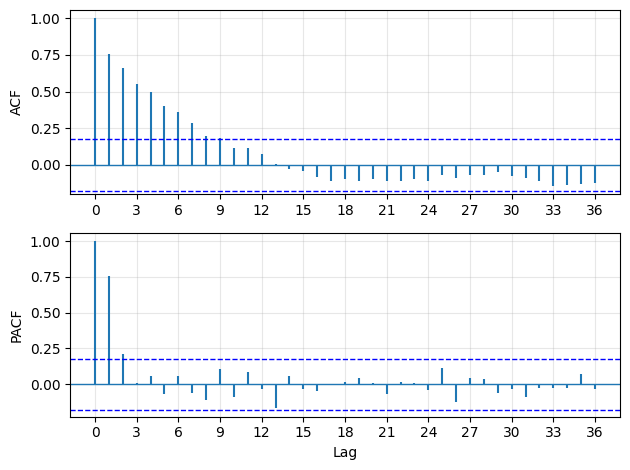

In [12]:
acf_pacf_fig(y, both=True, lag=36)
show_and_save("02_acf_pacf_mentah.png")

**Interpretasi:** Plot ACF turun secara perlahan (*tails off*), sementara PACF terlihat *cut-off* tajam setelah lag ke-2. Pola ACF yang turun lambat merupakan ciri khas deret yang **tidak stasioner** dalam nilai tengah.

### Uji Kestasioneran dalam Nilai Tengah

Digunakan uji akar-satuan **Augmented Dickey-Fuller (ADF)**:

$H_0$: deret tidak stasioner (terdapat akar unit), $H_1$: deret stasioner. Tolak $H_0$ jika p-value < 0.05.

Sebagai pembanding, digunakan uji **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** dengan hipotesis kebalikannya ($H_0$: stasioner).

In [13]:
_ = adf_report(y, "Data mentah")
print()
_ = kpss_report(y, "Data mentah")

[ADF] Data mentah
  Statistik ADF : -1.3165 | p-value = 0.6216 | lag = 3
  Critical value 1%: -3.4870
  Critical value 5%: -2.8864
  Critical value 10%: -2.5800
  Kesimpulan: TIDAK STASIONER (gagal tolak H0)

[KPSS] Data mentah
  Statistik KPSS: 0.5888 | p-value = 0.0237 | lag = 5
  Kesimpulan: TIDAK STASIONER (tolak H0)


Pada uji ADF, p-value yang diperoleh **jauh lebih besar dari 0,05**, sehingga kita **gagal tolak $H_0$** dan disimpulkan deret **tidak stasioner** dalam nilai tengah. Hasil ini konsisten dengan pola visual pada plot deret (adanya pergeseran level/tren, terutama kenaikan tajam sejak 2023) serta pola ACF yang turun lambat.

### Dekomposisi Deret Waktu

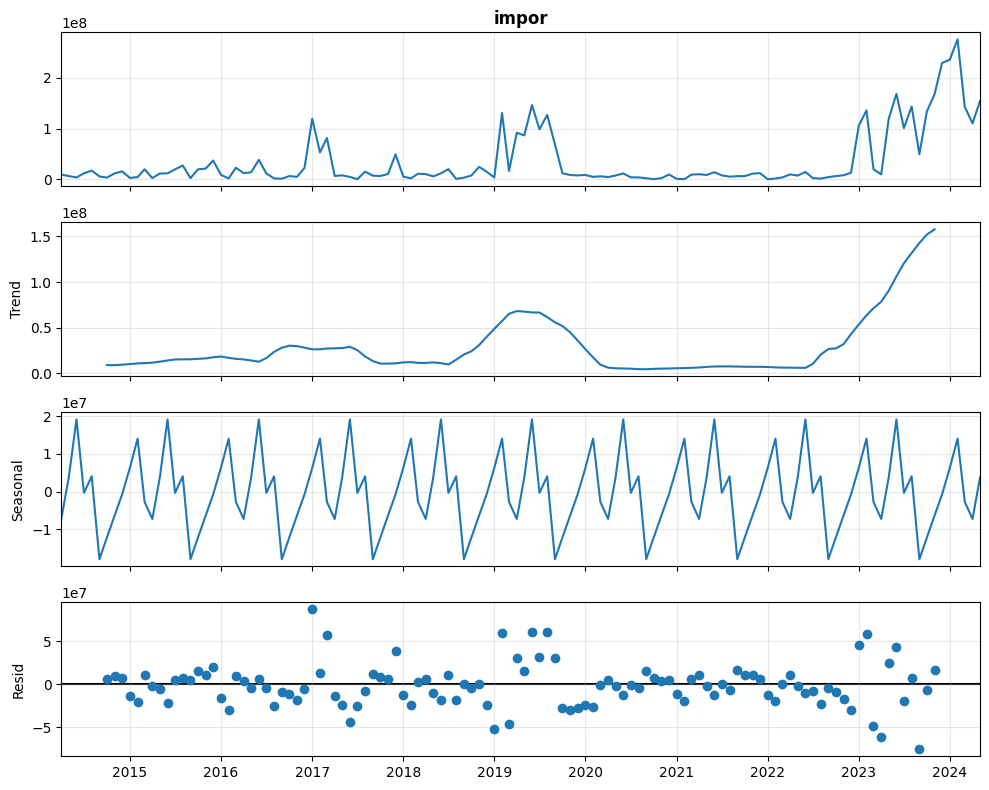

In [14]:
result = seasonal_decompose(y, model='additive', period=12)
fig = result.plot()
fig.set_size_inches(10, 8)
show_and_save("03_dekomposisi.png")

**Interpretasi:** Komponen *trend* memperlihatkan pergerakan naik-turun yang cukup besar dengan lonjakan signifikan di akhir periode (2023-2024), memperkuat indikasi ketidakstasioneran dalam nilai tengah. Komponen musiman relatif kecil dibandingkan trend dan residual, sesuai dengan sifat data impor yang lebih dipengaruhi kebijakan/kejadian eksternal dibanding pola musiman tetap.

### Korelasi (Autokorelasi) dan Scatterplot Lag

In [15]:
for lag in [1, 2, 3, 6, 12, 24]:
    print(f"Autokorelasi lag-{lag:<2d}: {y.autocorr(lag=lag):.4f}")

Autokorelasi lag-1 : 0.7708
Autokorelasi lag-2 : 0.6796
Autokorelasi lag-3 : 0.5827
Autokorelasi lag-6 : 0.5064
Autokorelasi lag-12: 0.1534
Autokorelasi lag-24: -0.1809


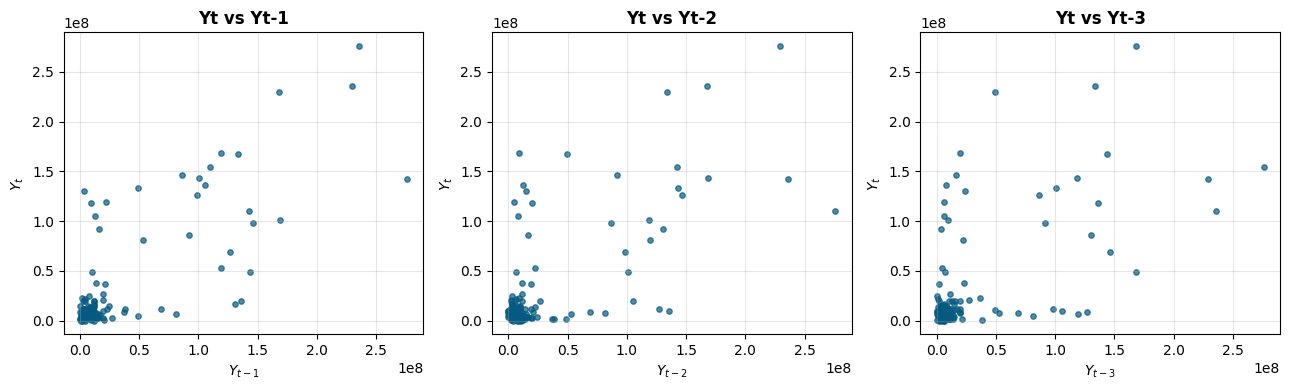

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, lag in enumerate([1, 2, 3]):
    axes[i].scatter(y.shift(lag), y, s=15, color="#065A82", alpha=0.7)
    axes[i].set_xlabel(f"$Y_{{t-{lag}}}$"); axes[i].set_ylabel("$Y_t$")
    axes[i].set_title(f"Yt vs Yt-{lag}")
show_and_save("06b_scatter_lag.png")

**Interpretasi:** Autokorelasi lag-1 cukup tinggi (0,77), menunjukkan nilai impor bulan ini berkorelasi kuat dengan bulan sebelumnya, dan melemah pada lag besar (indikasi pola musiman tahunan yang lemah). Pada scatterplot, pola searah paling jelas terlihat di lag-1 dan semakin acak pada lag-2 dan lag-3, konsisten dengan pola PACF yang *cut-off* setelah lag ke-2.

### Uji Kestasioneran dalam Ragam (Box-Cox)

Kestasioneran ragam diuji menggunakan **Box-Cox**. Jika nilai $\lambda = 1$ berada dalam interval kepercayaan $\lambda$ hasil transformasi, deret dapat dikatakan **stasioner dalam ragam**. Transformasi Box-Cox mensyaratkan data **bernilai positif** — data impor beras sudah seluruhnya positif (nilai minimum = 1), sehingga transformasi dapat langsung dilakukan tanpa pergeseran (*shifting*).

In [17]:
print("Nilai minimum data:", y.min())
print("Jumlah data <= 0   :", (y <= 0).sum())

Nilai minimum data: 1.0
Jumlah data <= 0   : 0


In [18]:
data_bc, lambda_fit, ci = boxcox(y, alpha=0.05)
print(f"Nilai lambda optimum: {lambda_fit:.4f}")
print(f"Interval kepercayaan 95% lambda: ({ci[0]:.4f}, {ci[1]:.4f})")
print("Apakah 1 masuk interval?:", "YA -> stasioner ragam" if ci[0] <= 1 <= ci[1] else "TIDAK -> belum stasioner ragam")

Nilai lambda optimum: 0.1749
Interval kepercayaan 95% lambda: (0.1268, 0.2315)
Apakah 1 masuk interval?: TIDAK -> belum stasioner ragam


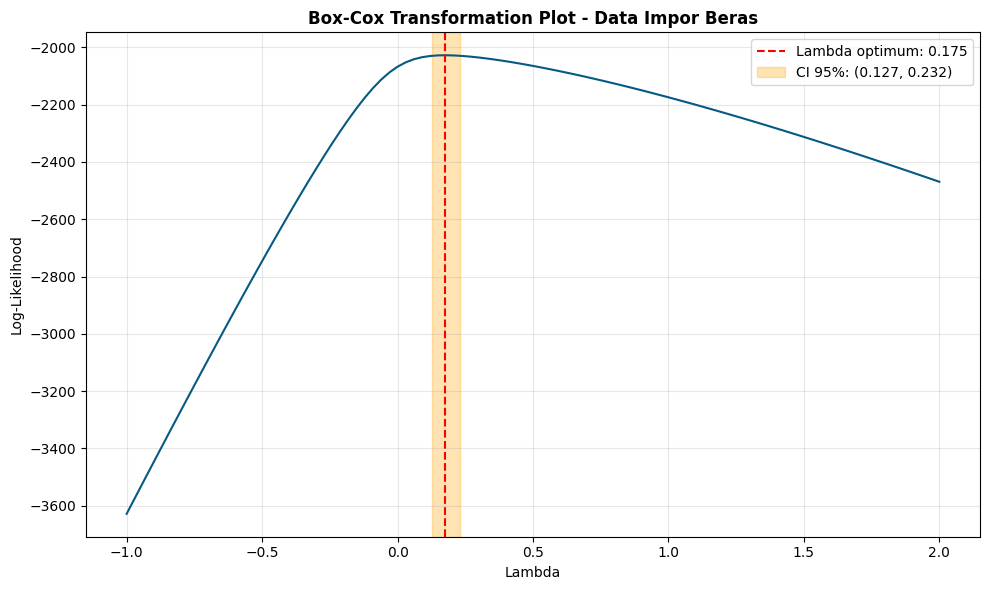

In [19]:
lambdas = np.linspace(-1, 2, 100)
llf = [boxcox_llf(l, y) for l in lambdas]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lambdas, llf, color="#065A82")
ax.axvline(lambda_fit, color='r', linestyle='--', label=f'Lambda optimum: {lambda_fit:.3f}')
ax.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'CI 95%: ({ci[0]:.3f}, {ci[1]:.3f})')
ax.set_xlabel('Lambda'); ax.set_ylabel('Log-Likelihood')
ax.set_title('Box-Cox Transformation Plot - Data Impor Beras')
ax.legend()
show_and_save("04_boxcox_plot.png")

**Interpretasi:** Karena nilai **1 tidak termasuk** dalam interval kepercayaan $\lambda$ yang diperoleh, deret impor beras **belum stasioner dalam ragam** dan perlu dilakukan transformasi.

### Transformasi Box-Cox

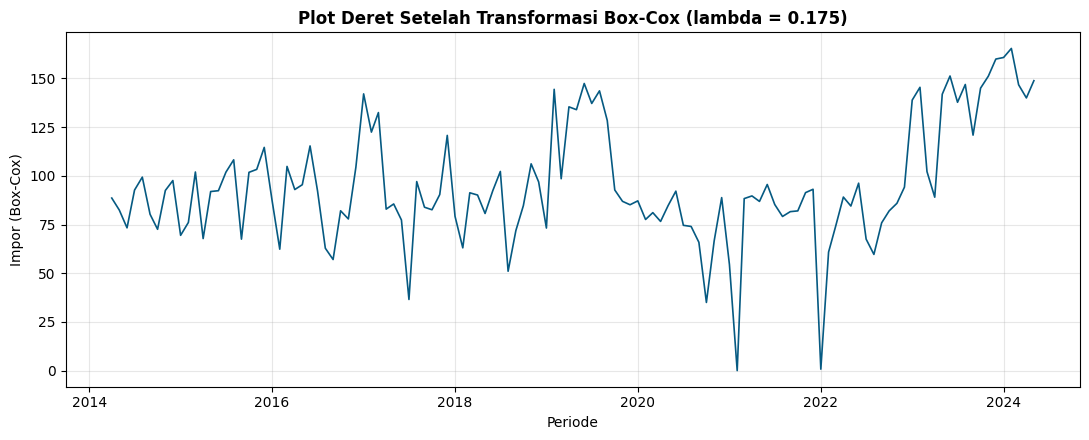

In [20]:
y_bc = boxcox(y, lmbda=lambda_fit)
y_bc = pd.Series(y_bc, index=y.index)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(y_bc.index, y_bc.values, color="#065A82", lw=1.2)
ax.set_title(f"Plot Deret Setelah Transformasi Box-Cox (lambda = {lambda_fit:.3f})")
ax.set_xlabel("Periode"); ax.set_ylabel("Impor (Box-Cox)")
show_and_save("05_plot_boxcox.png")

Setelah transformasi Box-Cox, skala nilai deret menjadi lebih rapat dan ragamnya lebih stabil, namun pola naik-turun level (terutama tren naik pada 2023-2024 dan level rendah pada 2020-2022) **masih terlihat**, mengindikasikan deret **masih belum stasioner dalam nilai tengah**.

In [21]:
_ = adf_report(y_bc, "Data Box-Cox")

[ADF] Data Box-Cox
  Statistik ADF : -2.7415 | p-value = 0.0671 | lag = 2
  Critical value 1%: -3.4865
  Critical value 5%: -2.8862
  Critical value 10%: -2.5799
  Kesimpulan: TIDAK STASIONER (gagal tolak H0)


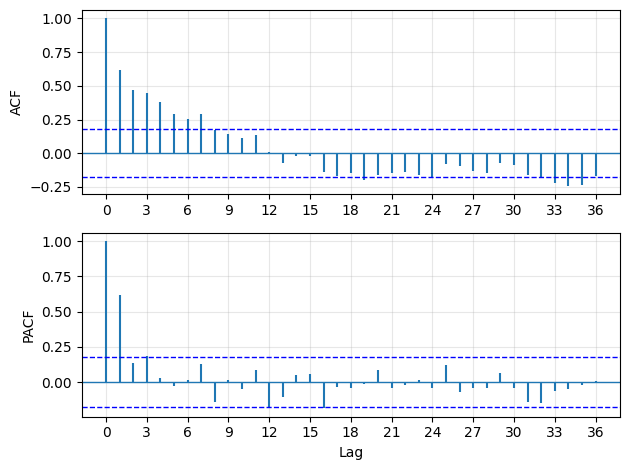

In [22]:
acf_pacf_fig(y_bc, both=True, lag=36)
show_and_save("06_acf_pacf_boxcox.png")

Karena p-value ADF masih lebih besar dari 0,05 dan pola ACF masih turun lambat, deret hasil transformasi Box-Cox **masih perlu dilakukan differencing** untuk mencapai kestasioneran nilai tengah.

### Differencing Orde-1

[ADF] Data Box-Cox - diff ke-1
  Statistik ADF : -6.9009 | p-value = 0.0000 | lag = 5
  Critical value 1%: -3.4885
  Critical value 5%: -2.8870
  Critical value 10%: -2.5804
  Kesimpulan: STASIONER (tolak H0)


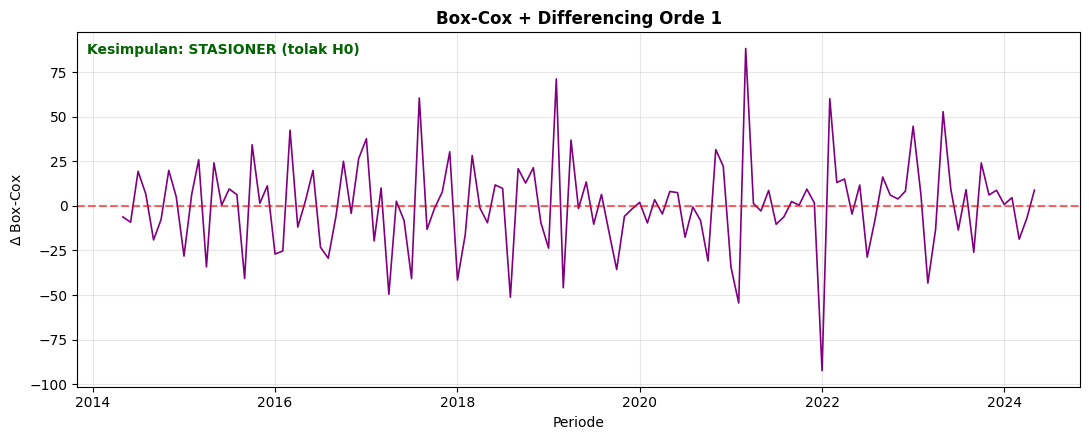

In [23]:
y_bc_diff1 = y_bc.diff().dropna()
adf_p3 = adf_report(y_bc_diff1, "Data Box-Cox - diff ke-1")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(y_bc_diff1.index, y_bc_diff1.values, color="purple", lw=1.2)
ax.axhline(0, color="red", ls="--", alpha=0.6)
ax.set_title("Box-Cox + Differencing Orde 1")
ax.set_xlabel("Periode"); ax.set_ylabel("$\Delta$ Box-Cox")
kesimpulan = "STASIONER (tolak H0)" if adf_p3 < 0.05 else "TIDAK STASIONER (gagal tolak H0)"
ax.text(0.01, 0.97, f"Kesimpulan: {kesimpulan}", transform=ax.transAxes,
        fontsize=10, fontweight="bold", color="darkgreen" if adf_p3 < 0.05 else "darkred",
        va="top")
show_and_save("07_plot_differencing.png")

In [24]:
_ = kpss_report(y_bc_diff1, "Data Box-Cox - diff ke-1")

[KPSS] Data Box-Cox - diff ke-1
  Statistik KPSS: 0.3618 | p-value = 0.0936 | lag = 82
  Kesimpulan: STASIONER (gagal tolak H0)


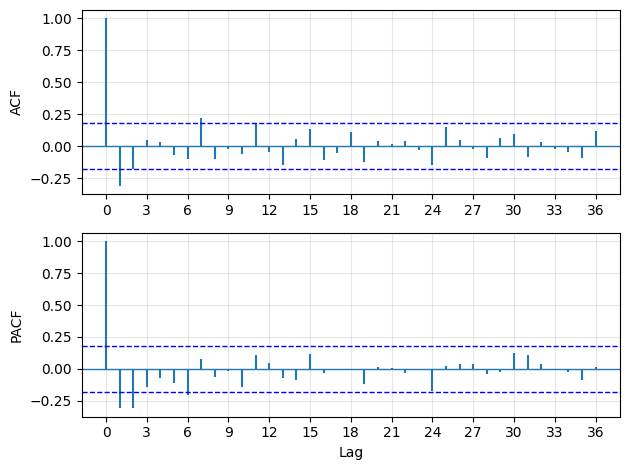

In [25]:
acf_pacf_fig(y_bc_diff1, both=True, lag=36)
show_and_save("08_acf_pacf_differencing.png")

**Interpretasi:** Setelah differencing orde-1, plot deret sudah berfluktuasi stabil di sekitar nilai 0 tanpa pola tren, meski masih terlihat dua lonjakan cukup besar (sekitar awal 2021 dan awal 2022) yang berasal dari dua nilai mentah yang sangat kecil/mendekati nol (Feb-2021 = 1 Kg, Jan-2022 = 2 Kg). Meski demikian, p-value ADF menjadi sangat kecil (< 0,05, tolak $H_0$ → **stasioner**), dan hasil ini didukung oleh plot ACF yang sudah *cut-off* cepat. Perhatian terhadap kedua titik ekstrem tersebut tetap perlu dibawa ke tahap pemodelan ARIMA selanjutnya (misalnya melalui intervensi/dummy variable atau penanganan outlier, bila hasil diagnostik model nantinya menunjukkan residual masih terpengaruh oleh kedua titik ini).

### Mengembalikan Transformasi ke Nilai/Skala Semula (Inverse Box-Cox)

In [26]:
y_inverse = pd.Series(inv_boxcox(y_bc, lambda_fit), index=y_bc.index)

comparison = pd.DataFrame({"y_asli": y, "y_inverse_boxcox": y_inverse})
mae = np.abs(comparison["y_asli"] - comparison["y_inverse_boxcox"]).mean()
print(f"Mean Absolute Error (data asli vs inverse Box-Cox): {mae:.6f}")
comparison.head()

Mean Absolute Error (data asli vs inverse Box-Cox): 0.000000


,y_asli,y_inverse_boxcox
period,,
2014-04-01,9150000.0,9150000.0
2014-05-01,6225000.0,6225000.0
2014-06-01,3325000.0,3325000.0
2014-07-01,11668000.0,11668000.0
2014-08-01,16949925.0,16949925.0


MAE yang diperoleh mendekati nol, membuktikan bahwa transformasi Box-Cox yang dilakukan dapat dikembalikan secara tepat ke nilai/skala semula, sehingga interpretasi akhir tetap dapat disajikan dalam satuan volume impor beras yang sesungguhnya (Kg).

## Kesimpulan Eksplorasi

1. Teridentifikasi beberapa **nilai ekstrem** pada data impor beras (metode IQR skala log), baik di sisi atas (lonjakan besar terkait kebijakan/krisis pangan, terutama 2019 dan 2023-2024) maupun di sisi bawah/mendekati nol (Feb-2021, Jan-2022, yang patut dicurigai sebagai kesalahan pencatatan). **Penanganan nilai-nilai ini belum dilakukan pada tahap EDA ini** dan akan diputuskan bersama pada tahap pemodelan ARIMA.
2. Data impor beras Indonesia (April 2014 - Mei 2024) pada level aslinya **tidak stasioner**, baik dalam **nilai tengah** (uji ADF gagal tolak H0, ACF turun lambat, ada pergeseran level terutama tren naik sejak 2023) maupun dalam **ragam** (rentang nilai sangat lebar, nilai 1 tidak masuk CI lambda Box-Cox).
3. Transformasi **Box-Cox** dengan $\lambda$ optimum hasil estimasi (dari data mentah) berhasil menstabilkan ragam, namun nilai tengah masih belum stasioner.
4. **Differencing orde-1** pada data hasil Box-Cox berhasil membuat deret stasioner dalam nilai tengah (didukung uji ADF), meski masih terlihat dua lonjakan besar yang berasal dari dua nilai ekstrem mentah yang belum ditangani.
5. Urutan penanganan yang digunakan pada eksplorasi ini adalah **transformasi Box-Cox (menstabilkan ragam) terlebih dahulu, kemudian differencing** (menstabilkan nilai tengah), tanpa penanganan outlier terlebih dahulu.
6. Transformasi Box-Cox bersifat *reversible* (MAE inverse mendekati nol), sehingga interpretasi akhir model dapat disajikan dalam satuan volume impor beras yang sesungguhnya.
7. Hasil eksplorasi ini menjadi dasar identifikasi model ARIMA(p,1,q) pada tahap pemodelan selanjutnya. Pada tahap tersebut, kelompok akan mempertimbangkan kembali apakah kedua nilai ekstrem yang teridentifikasi perlu ditangani (misalnya melalui interpolasi log-linear) berdasarkan hasil diagnostik model.